# 02 — VAR (Vector Autoregression)

VAR models the weekly silver return and companion variables as a joint system: each equation uses
lags of silver and lags of every other series in that system. The forecasting workflow below mirrors
`01_arima`, `04_random_forest`, and `05_xgboost`: shared weekly frame, train+val lag selection,
expanding and rolling walk-forward variants, Drift-floor evaluation, dual RMSE/WDA selection,
and the same DM / PT / ex-2025 test battery.

VAR-specific interpretation is kept, but moved after the forecast evaluation:
- **Granger causality tests** — whether a variable's lags add predictive information for silver.
- **Impulse responses** — how shocks propagate through the fitted VAR system.


## 0. Model intuition

A VAR treats the variables in a system as jointly endogenous. Let

$$
\mathbf z_t =
\begin{bmatrix}
 r^{silver}_t & r^{gold}_t & r^{usd}_t & \cdots
\end{bmatrix}'
$$

be the vector of weekly returns / signals included in one VAR rung. A VAR($p$) is

$$
\mathbf z_t = \mathbf c + A_1 \mathbf z_{t-1} + A_2 \mathbf z_{t-2} + \cdots + A_p \mathbf z_{t-p} + \mathbf u_t,
\qquad \mathbf u_t \sim (0, \Sigma_u).
$$

The silver equation inside that system is just one row of the VAR:

$$
r^{silver}_t
= c_s
+ \sum_{i=1}^{p} \phi_i r^{silver}_{t-i}
+ \sum_{j \neq silver}\sum_{i=1}^{p} \theta_{j,i} z_{j,t-i}
+ u_{s,t}.
$$

So, unlike ARIMAX where non-silver variables are supplied as exogenous regressors, VAR lets each
variable be forecast from the lagged system. The one-step-ahead forecast is

$$
\widehat{\mathbf z}_{t|t-1}
= \widehat{\mathbf c} + \widehat A_1 \mathbf z_{t-1} + \cdots + \widehat A_p \mathbf z_{t-p},
$$

and this notebook evaluates only the silver component, $\widehat r^{silver}_{t|t-1}$. The lag order
$p$ is selected separately for each system by BIC on train+val.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120


## 1. Load features

All weekly models read the shared W-FRI frame built by `02_features.ipynb` §8. For VAR, feature
columns enter as endogenous system variables; the one-week forecasting lag comes from the fitted VAR
lag itself rather than from manually shifted regressors. The BestLag and monthly macro columns are
already availability-lagged in the frame and are consumed as-is.


In [17]:
import json

# Weekly feature frame (built once by 02_features.ipynb §8 — single source of truth).
weekly = pd.read_csv('../../data/processed/features_weekly.csv', index_col=0, parse_dates=True)
with open('../../data/processed/feature_groups.json') as f:
    GROUPS = json.load(f)

TARGET = 'silver_return'
WINDOW = 100

# The VAR base system mirrors the public cross-asset EXOG block used elsewhere.
EXOG_RETURNS = [c for c in ['gold_return', 'usd_return', 'copper_return',
                            'sp500_return', 'vix_return', 'oil_return']
                if c in weekly.columns]

# Common target/index used by every variant so forecast arrays align exactly with the shared test set.
target_frame = weekly[[TARGET, 'split']].dropna().copy()
n_train = int((target_frame['split'] != 'test').sum())
y_test = target_frame[TARGET].iloc[n_train:].values
test_index = target_frame.index[n_train:]

print(f'Weekly obs — train+val: {n_train}, test: {len(y_test)}')
print(f'EXOG returns ({len(EXOG_RETURNS)}): {EXOG_RETURNS}')


Weekly obs — train+val: 417, test: 174
EXOG returns (6): ['gold_return', 'usd_return', 'copper_return', 'sp500_return', 'vix_return', 'oil_return']


## 2. Build endogenous systems + lag selection

Each ladder rung is a different VAR system. The target is always included, so its own lags are part
of every model by construction; this is why VAR does not need separate `silver_lag1/2/3` columns.
For comparability with the other notebooks, the rungs follow the same EXOG / Tech / GS / FRED / COT /
Sentiment / BestLag pattern, but the interpretation is "add these variables to the system" rather
than "add these columns as exogenous regressors."


In [18]:
def series_dict(cols):
    """Return {column_name: weekly_series} for columns present in the shared frame."""
    return {c: weekly[c] for c in cols if c in weekly.columns}

GS_COLS       = series_dict(GROUPS['GS'])
FRED_COLS     = series_dict(GROUPS['FRED_DAILY'])
COT_COLS      = series_dict(GROUPS['COT'])
SENT_COLS     = series_dict(GROUPS['SENT'])
REDDIT_COLS   = {'reddit_sentiment': SENT_COLS['reddit_sentiment']} if 'reddit_sentiment' in SENT_COLS else {}
NEWS_COLS     = {'news_sentiment':   SENT_COLS['news_sentiment']}   if 'news_sentiment'   in SENT_COLS else {}
MACRO_COLS    = series_dict(GROUPS['MACRO'])       # leak-corrected monthly availability lags
TECH_COLS     = series_dict(GROUPS['TECH'])
BESTLAG_ALL_COLS   = series_dict(GROUPS['BESTLAG_ALL'])   # pre-lagged (used as-is)
BESTLAG_SIG90_COLS = series_dict(GROUPS['BESTLAG_SIG90'])
BESTLAG_SIG_COLS   = series_dict(GROUPS['BESTLAG_SIG'])

BASE_RETURNS = series_dict(EXOG_RETURNS)
NONLIN_COLS  = {f'{c}_sq': weekly[c] ** 2 for c in [TARGET] + EXOG_RETURNS if c in weekly.columns}
MACROCOT_COLS = {**FRED_COLS, **COT_COLS}
ALL_EXTRA = {**GS_COLS, **NONLIN_COLS, **TECH_COLS, **MACROCOT_COLS, **SENT_COLS}


def make_system(extra_cols=None):
    """Build one aligned VAR system: target + selected system variables.

    Missing feature values are forward-filled from already-observed history and remaining warm-up
    gaps are set to 0, matching the neutral-fill convention used by the older VAR sentiment cell and
    avoiding test-period backfills.
    """
    df = pd.DataFrame(index=target_frame.index)
    df[TARGET] = target_frame[TARGET]
    for name, series in (extra_cols or {}).items():
        if name == TARGET:
            continue
        df[name] = pd.to_numeric(series.reindex(df.index), errors='coerce')
    feature_cols = [c for c in df.columns if c != TARGET]
    if feature_cols:
        df[feature_cols] = df[feature_cols].ffill().fillna(0.0)
        # Statsmodels VAR cannot estimate a constant column alongside its intercept.
        constant_cols = [c for c in feature_cols if df[c].iloc[:n_train].nunique(dropna=True) <= 1]
        if constant_cols:
            df = df.drop(columns=constant_cols)
    return df.dropna()


def _safe_maxlags(nobs, k_vars, requested=8, rolling_window=WINDOW):
    # Keep lag search feasible for both expanding and 100w rolling fits.
    limiting_nobs = min(nobs, rolling_window) if rolling_window else nobs
    max_by_params = max(1, (limiting_nobs - 2) // (k_vars + 1))
    return max(1, min(requested, max_by_params, nobs - 2))


def select_var_lag(system, maxlags=8, criterion='bic'):
    """Select VAR lag on train+val only, with a conservative feasibility cap."""
    train_system = system.iloc[:n_train].dropna()
    k_vars = train_system.shape[1]
    lag_cap = _safe_maxlags(len(train_system), k_vars, requested=maxlags)
    last_err = None
    for cap in range(lag_cap, 0, -1):
        try:
            sel = VAR(train_system).select_order(maxlags=cap)
            chosen = getattr(sel, criterion)
            if chosen is None or (isinstance(chosen, float) and np.isnan(chosen)):
                chosen = 1
            return max(int(chosen), 1), sel, cap
        except Exception as err:
            last_err = err
    print(f'Lag selection failed ({last_err}); falling back to VAR(1).')
    return 1, None, 1

base_system = make_system(BASE_RETURNS)
base_lag, base_lag_results, base_lag_cap = select_var_lag(base_system, maxlags=10)
print(f'Base VAR system: {base_system.shape[1]} variables, lag-search cap={base_lag_cap}')
if base_lag_results is not None:
    print(base_lag_results.summary())
print(f'Using base BIC lag for diagnostics: {base_lag}')


Base VAR system: 7 variables, lag-search cap=10
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -49.89     -49.82*   2.149e-22     -49.86*
1       -49.95      -49.40   2.027e-22      -49.73
2       -49.93      -48.90   2.060e-22      -49.53
3       -49.99      -48.47   1.957e-22      -49.39
4      -49.99*      -47.99  1.952e-22*      -49.20
5       -49.96      -47.47   2.023e-22      -48.97
6       -49.88      -46.92   2.182e-22      -48.71
7       -49.87      -46.42   2.221e-22      -48.50
8       -49.74      -45.81   2.530e-22      -48.19
9       -49.68      -45.27   2.699e-22      -47.94
10      -49.57      -44.68   3.031e-22      -47.64
--------------------------------------------------
Using base BIC lag for diagnostics: 1


## 3. Walk-forward helpers

At each test week $t$, the model forecasts one week ahead using observations available before $t$.
Coefficients are re-estimated every 4 forecast steps, matching the RF/XGB walk-forward cadence; the
history used for the forecast still advances one week at a time. Both expanding and rolling-100w
windows are run for every rung, and only the silver equation's forecast is evaluated.


In [19]:
def var_walk_forward(system, n_train, lag, window=None, retrain_every=4):
    """window=None -> expanding; window=N -> rolling (last N weeks)."""
    silver_col = system.columns.get_loc(TARGET)
    preds = np.full(len(system) - n_train, np.nan)
    min_rows = system.shape[1] * lag + lag + 2
    model = None
    for i, t in enumerate(range(n_train, len(system))):
        start = max(0, t - window) if window else 0
        history = system.iloc[start:t].dropna()
        if len(history) < min_rows:
            model = None
            continue
        try:
            if model is None or i % retrain_every == 0:
                model = VAR(history).fit(lag)
            fc = model.forecast(history.values[-lag:], steps=1)
            preds[i] = fc[0, silver_col]
        except Exception:
            model = None
    return preds


def run_variant(label, extra_cols, maxlags=8):
    """Select lag on this system, then walk-forward both windows."""
    system = make_system(extra_cols)
    lag, _, lag_cap = select_var_lag(system, maxlags=maxlags)
    print(f'--- {label} | k={system.shape[1]} | lag={lag} (cap={lag_cap}) ---', flush=True)
    p_exp = var_walk_forward(system, n_train, lag, window=None)
    p_rol = var_walk_forward(system, n_train, lag, window=WINDOW)
    evaluate(f'{label} expanding',      y_test, p_exp)
    evaluate(f'{label} rolling (100w)', y_test, p_rol)
    all_candidates[f'{label} expanding']      = p_exp
    all_candidates[f'{label} rolling (100w)'] = p_rol
    variant_info[label] = {'k_vars': system.shape[1], 'lag': lag, 'lag_cap': lag_cap,
                           'columns': system.columns.tolist()}


## 4. Variant ladder

Every rung is forecast in both windows. `EXOG` is the base cross-asset return system. `Tech` and the
BestLag rungs use silver plus that group only, mirroring the tree notebooks' "own-history + selected
signals" setup; all other rungs build on EXOG. `EXOG+ALL` is intentionally a forecasting ablation, not
a structurally interpreted VAR.


In [20]:
import sys, os
sys.path.insert(0, os.path.abspath('../../src'))
from eval_utils import evaluate, period_metrics, diebold_mariano, oos_r2, PERIODS

all_candidates = {}
variant_info = {}

run_variant('EXOG',                  BASE_RETURNS, maxlags=10)     # rung 0 -- public cross-assets
run_variant('Tech',                  TECH_COLS)
run_variant('EXOG+GS',               {**BASE_RETURNS, **GS_COLS})
run_variant('EXOG+NonLin',           {**BASE_RETURNS, **NONLIN_COLS})
run_variant('EXOG+Tech',             {**BASE_RETURNS, **TECH_COLS})
run_variant('EXOG+Macro',            {**BASE_RETURNS, **MACRO_COLS})
run_variant('EXOG+FRED_daily',       {**BASE_RETURNS, **FRED_COLS})
run_variant('EXOG+COT',              {**BASE_RETURNS, **COT_COLS})
run_variant('EXOG+FRED_daily+COT',   {**BASE_RETURNS, **MACROCOT_COLS})
run_variant('EXOG+Reddit+News',      {**BASE_RETURNS, **SENT_COLS})
run_variant('EXOG+Reddit',           {**BASE_RETURNS, **REDDIT_COLS})
run_variant('EXOG+News',             {**BASE_RETURNS, **NEWS_COLS})
run_variant('EXOG+GS+Sentiment',     {**BASE_RETURNS, **GS_COLS, **SENT_COLS})
run_variant('EXOG+NonLin+Sentiment', {**BASE_RETURNS, **NONLIN_COLS, **SENT_COLS})
run_variant('EXOG+Tech+Sentiment',   {**BASE_RETURNS, **TECH_COLS, **SENT_COLS})
run_variant('EXOG+ALL',              {**BASE_RETURNS, **ALL_EXTRA})
run_variant('BestLag-All',           BESTLAG_ALL_COLS)
run_variant('BestLag-Sig90',         BESTLAG_SIG90_COLS)
run_variant('BestLag-Sig',           BESTLAG_SIG_COLS)

variant_info_df = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != 'columns'}
                                for k, v in variant_info.items()}).T
variant_info_df


--- EXOG | k=7 | lag=1 (cap=10) ---
EXOG expanding                                 RMSE=0.05231  MAE=0.03701  DA=0.552  WDA=0.515
EXOG rolling (100w)                            RMSE=0.05364  MAE=0.03788  DA=0.500  WDA=0.490
Lag selection failed (3-th leading minor of the array is not positive definite); falling back to VAR(1).
--- Tech | k=11 | lag=1 (cap=1) ---
Tech expanding                                 RMSE=0.05921  MAE=0.03988  DA=0.511  WDA=0.524
Tech rolling (100w)                            RMSE=0.06718  MAE=0.04572  DA=0.471  WDA=0.475
--- EXOG+GS | k=8 | lag=1 (cap=8) ---
EXOG+GS expanding                              RMSE=0.05206  MAE=0.03677  DA=0.586  WDA=0.599
EXOG+GS rolling (100w)                         RMSE=0.05545  MAE=0.03855  DA=0.529  WDA=0.521
--- EXOG+NonLin | k=14 | lag=1 (cap=6) ---
EXOG+NonLin expanding                          RMSE=0.05354  MAE=0.03890  DA=0.523  WDA=0.543
EXOG+NonLin rolling (100w)                     RMSE=0.06038  MAE=0.04276  DA=0.437  

,k_vars,lag,lag_cap
EXOG,7,1,10
Tech,11,1,1
EXOG+GS,8,1,8
EXOG+NonLin,14,1,6
EXOG+Tech,17,1,1
EXOG+Macro,19,4,4
EXOG+FRED_daily,10,1,8
EXOG+COT,9,1,8
EXOG+FRED_daily+COT,12,1,7
EXOG+Reddit+News,9,1,8


## 5. Evaluate

One table — RMSE / MAE / DA / WDA for the benchmarks and every VAR system (both windows). **Drift
(prevailing mean = random-walk-with-drift floor)** is the benchmark for the significance tests;
`Naive` is kept only as a weak reference.


**Metrics** — RMSE / MAE (point-forecast error, magnitude), OOS R² (effect size vs Drift, shown as `r2_os`), DA / WDA (directional). Formulas, caveats, and load-bearing status: `01_arima` §5 or [`tests.md`](tests.md).


In [21]:
# Naive: 1-step persistence. Kept at y_test[1:] to match the other weekly notebooks.
naive_pred = target_frame[TARGET].iloc[n_train-1:-1].values
naive_m = evaluate('Naive (t-1 week)', y_test[1:], naive_pred[1:])
if naive_m:
    naive_m['r2_os'] = float('nan')   # different y length -- OOS R^2 not comparable

# Drift / random-walk-with-drift: prevailing expanding mean of all returns observed before week t.
_hist = list(target_frame[TARGET].iloc[:n_train].values)
drift_pred = np.empty(len(y_test))
for _t, _actual in enumerate(y_test):
    drift_pred[_t] = np.mean(_hist)
    _hist.append(float(_actual))

valid_candidates = {name: np.asarray(pred, dtype=float)
                    for name, pred in all_candidates.items()
                    if np.isfinite(np.asarray(pred, dtype=float)).sum() >= 4}
print(f'Valid VAR candidates: {len(valid_candidates)}/{len(all_candidates)}')

# Drift + all valid variants at full test length; r2_os computed inline (0 for Drift itself).
eval_preds = {'Drift (prevailing mean)': drift_pred, **valid_candidates}
main_evals = []
for name, pred in eval_preds.items():
    m = evaluate(name, y_test, pred)
    if m:
        m['r2_os'] = oos_r2(y_test, pred, drift_pred) * 100
        main_evals.append(m)

metrics_df = pd.DataFrame(([naive_m] if naive_m else []) + main_evals)
metrics_df = metrics_df[['model', 'rmse', 'mae', 'r2_os', 'dir_acc', 'wda']]
metrics_df.to_csv('../../data/processed/metrics_var.csv', index=False)

# Drift WDA by period (Drift's sign is usually positive = the always-up line; the WDA to beat).
_yt = pd.Series(y_test, index=test_index)
print('\nDrift WDA by period (directional benchmark to beat):')
for _lbl, (_a, _b) in PERIODS.items():
    _s = _yt.loc[_a:_b]
    if len(_s):
        _au = np.sum(np.abs(_s.values) * (_s.values > 0)) / np.sum(np.abs(_s.values))
        print(f'  {_lbl:20s} WDA={_au:.3f}  (n={len(_s)})')

metrics_df


Naive (t-1 week)                               RMSE=0.07594  MAE=0.05397  DA=0.491  WDA=0.490
Valid VAR candidates: 38/38
Drift (prevailing mean)                        RMSE=0.05190  MAE=0.03714  DA=0.557  WDA=0.588
EXOG expanding                                 RMSE=0.05231  MAE=0.03701  DA=0.552  WDA=0.515
EXOG rolling (100w)                            RMSE=0.05364  MAE=0.03788  DA=0.500  WDA=0.490
Tech expanding                                 RMSE=0.05921  MAE=0.03988  DA=0.511  WDA=0.524
Tech rolling (100w)                            RMSE=0.06718  MAE=0.04572  DA=0.471  WDA=0.475
EXOG+GS expanding                              RMSE=0.05206  MAE=0.03677  DA=0.586  WDA=0.599
EXOG+GS rolling (100w)                         RMSE=0.05545  MAE=0.03855  DA=0.529  WDA=0.521
EXOG+NonLin expanding                          RMSE=0.05354  MAE=0.03890  DA=0.523  WDA=0.543
EXOG+NonLin rolling (100w)                     RMSE=0.06038  MAE=0.04276  DA=0.437  WDA=0.427
EXOG+Tech expanding             

,model,rmse,mae,r2_os,dir_acc,wda
0,Naive (t-1 week),0.075941,0.053966,NaN,0.491329,0.489862
1,Drift (prevailing mean),0.051902,0.037135,0.000000,0.557471,0.587779
2,EXOG expanding,0.052310,0.037006,-1.578798,0.551724,0.515429
3,EXOG rolling (100w),0.053639,0.037881,-6.804037,0.500000,0.490473
4,Tech expanding,0.059212,0.039877,-30.149167,0.511494,0.524345
5,Tech rolling (100w),0.067179,0.045723,-67.531189,0.471264,0.475327
6,EXOG+GS expanding,0.052058,0.036775,-0.600817,0.586207,0.599417
7,EXOG+GS rolling (100w),0.055451,0.038551,-14.143699,0.528736,0.520524
8,EXOG+NonLin expanding,0.053545,0.038905,-6.430145,0.522989,0.543307
9,EXOG+NonLin rolling (100w),0.060376,0.042759,-35.316520,0.436782,0.426970


## 6. Sub-period robustness + best-variant selection

Pick the best VAR system two ways — by **RMSE** (primary, magnitude) and by **WDA** (secondary,
directional) — and break each down by calendar period. WDA-best keeps the legacy filenames used by
`evaluation.ipynb`; RMSE-best is saved alongside.


In [22]:
def _best_by_wda(candidates, actual):
    return max(candidates, key=lambda k:
        np.nansum(np.abs(actual) * (np.sign(actual) == np.sign(candidates[k]))) /
        np.nansum(np.abs(actual)))


def _best_by_rmse(candidates, actual):
    return min(candidates, key=lambda k:
        np.sqrt(np.nanmean((actual - candidates[k]) ** 2)))


def _period_r2(pred):
    drift_s, pred_s = pd.Series(drift_pred, index=test_index), pd.Series(pred, index=test_index)
    r2 = {}
    for _lbl, (_a, _b) in PERIODS.items():
        _y  = pd.Series(y_test, index=test_index).loc[_a:_b].values
        _p  = pred_s.loc[_a:_b].values
        _d  = drift_s.loc[_a:_b].values
        if len(_y):
            r2[_lbl] = oos_r2(_y, _p, _d) * 100
    return r2


def _show_period(pred, csv=None):
    res = period_metrics(y_test, pred, test_index, PERIODS)
    r2  = _period_r2(pred)
    res['R2_OS'] = [r2.get(lbl, float('nan')) for lbl in res.index]
    display(res[['n', 'RMSE', 'MAE', 'R2_OS', 'DA', 'WDA']].style
            .format({'n': '{:.0f}', 'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R2_OS': '{:+.2f}',
                     'DA': '{:.3f}', 'WDA': '{:.3f}'})
            .background_gradient(cmap='RdYlGn', subset=['DA', 'WDA'], vmin=0.4, vmax=0.7))
    if csv:
        res[['n', 'DA', 'WDA']].to_csv(csv)   # legacy schema -- evaluation.ipynb reads these


def _save_preds(pred, csv):
    pd.DataFrame({'actual': y_test, 'predicted': pred}, index=test_index) \
      .rename_axis('Date').to_csv(csv)

best_name      = _best_by_wda(valid_candidates, y_test)
best_name_rmse = _best_by_rmse(valid_candidates, y_test)
best_pred      = valid_candidates[best_name]
best_pred_rmse = valid_candidates[best_name_rmse]
print('Best VAR variant -- WDA:', best_name, '|  RMSE:', best_name_rmse)

print('\nDrift (prevailing mean) by period -- the floor:')
_show_period(drift_pred)

print('\nWDA-best by period:')
_show_period(best_pred,      '../../data/processed/period_var_weekly.csv')
print('RMSE-best by period:')
_show_period(best_pred_rmse, '../../data/processed/period_var_rmse_weekly.csv')

_save_preds(best_pred,      '../../data/processed/preds_var_best_weekly.csv')
_save_preds(best_pred_rmse, '../../data/processed/preds_var_bestrmse_weekly.csv')
print('\nSaved: metrics, period + preds (WDA-best legacy names, RMSE-best alongside).')


Best VAR variant -- WDA: EXOG+COT rolling (100w) |  RMSE: EXOG+GS+Sentiment expanding

Drift (prevailing mean) by period -- the floor:


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0400,0.0318,+0.00,0.481,0.492
2024 (bull start),52,0.0380,0.0299,+0.00,0.500,0.570
2025 (bull run),52,0.0498,0.0352,+0.00,0.692,0.757
2026 (YTD),18,0.1003,0.0791,+0.00,0.556,0.498
── Full test ──,174,0.0519,0.0371,+0.00,0.557,0.588



WDA-best by period:


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0401,0.0322,-0.69,0.635,0.677
2024 (bull start),52,0.0452,0.0337,-41.71,0.596,0.561
2025 (bull run),52,0.0472,0.0342,+10.42,0.635,0.793
2026 (YTD),18,0.1130,0.0874,-26.80,0.556,0.488
── Full test ──,174,0.0555,0.0390,-14.29,0.615,0.641


RMSE-best by period:


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0389,0.0305,+5.24,0.654,0.670
2024 (bull start),52,0.0367,0.0287,+6.75,0.635,0.702
2025 (bull run),52,0.0508,0.0359,-3.86,0.577,0.559
2026 (YTD),18,0.1010,0.0787,-1.39,0.444,0.433
── Full test ──,174,0.0518,0.0366,+0.41,0.603,0.594



Saved: metrics, period + preds (WDA-best legacy names, RMSE-best alongside).


## 7. Predicted vs actual — best VAR vs drift

Full test window, **two panels**: top = WDA-best (directional pick), bottom = RMSE-best (magnitude
pick). The drift floor is overlaid so any lift over the random walk is visible.


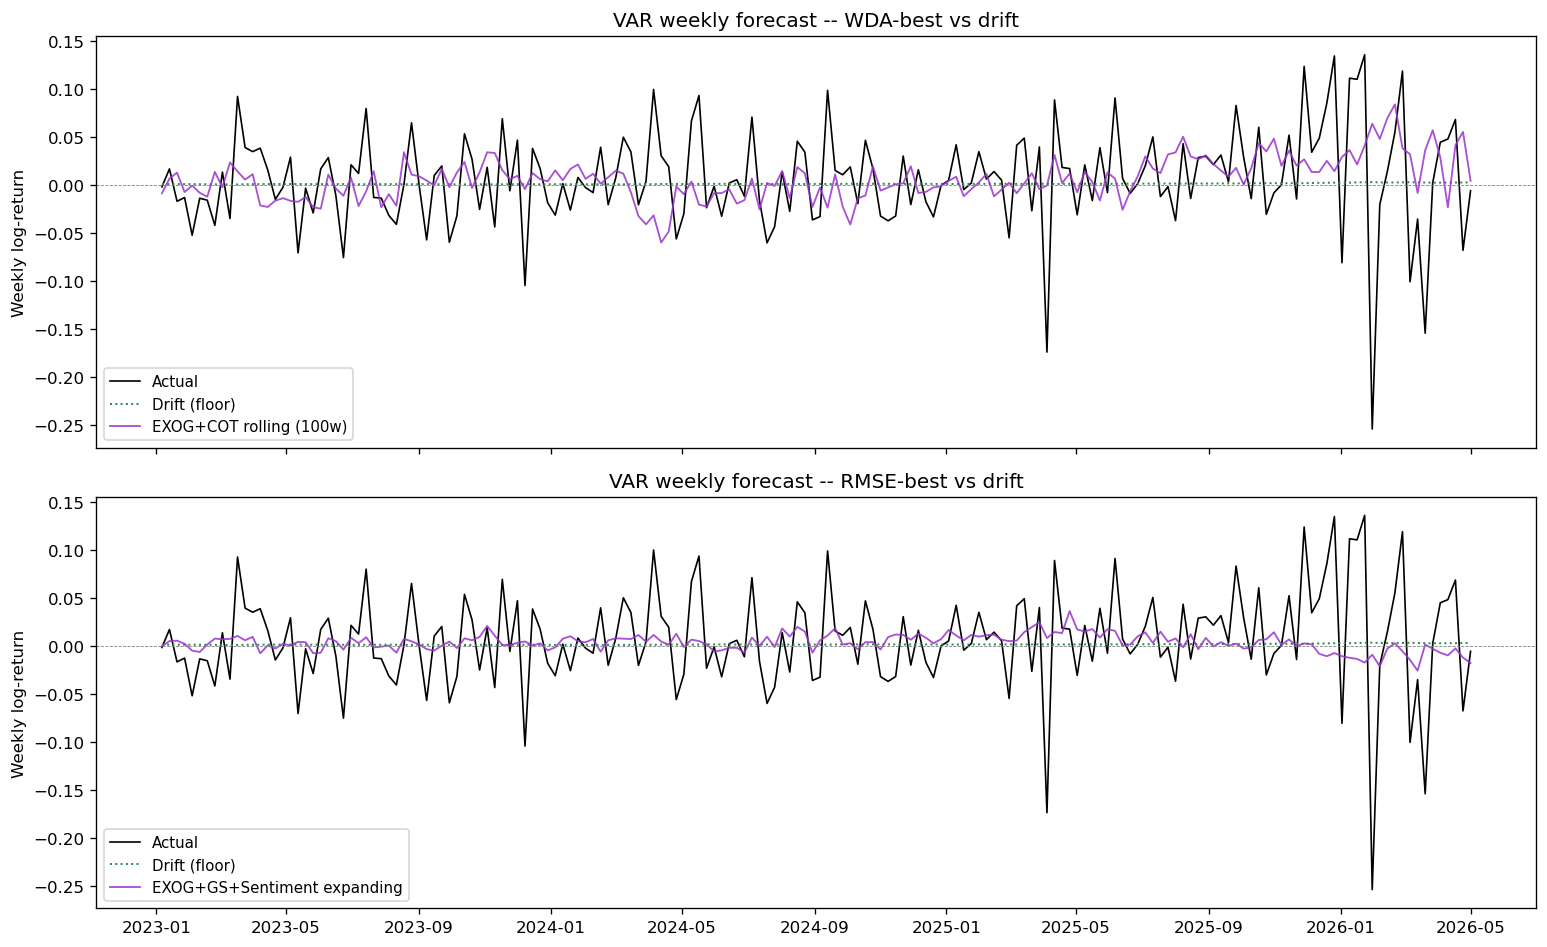

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
panels = [('WDA-best', best_name, best_pred), ('RMSE-best', best_name_rmse, best_pred_rmse)]
for ax, (tag, vname, vpred) in zip(axes, panels):
    ax.plot(test_index, y_test,     label='Actual',        lw=1,   color='black')
    ax.plot(test_index, drift_pred, label='Drift (floor)', lw=1.2, ls=':', color='seagreen')
    ax.plot(test_index, vpred,      label=vname,           lw=1.1, alpha=0.85, color='darkorchid')
    ax.axhline(0, color='grey', lw=0.5, ls='--')
    ax.set_title(f'VAR weekly forecast -- {tag} vs drift')
    ax.set_ylabel('Weekly log-return')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 8. Significance tests

The descriptive metrics in §5 rank the models; this section asks whether the differences are
**statistically real**. All tests are vs the **Drift** floor (prevailing mean = random walk). Because
VAR systems bundle silver's own lags with public cross-asset/news/macro information, this is a
semi-strong forecast test; ARIMA remains the clean weak-form isolation. Full definitions and
Newey–West detail: `01_arima` §8 and [`tests.md`](tests.md).

| Test | Asks | Axis | Role |
|---|---|---|---|
| **DM — squared error** | Does any VAR system beat the random walk? | magnitude | **load-bearing** |
| **DM — absolute error** | Does that survive heavy tails? | magnitude | robustness |
| **Pesaran–Timmermann** (§8b) | Do the sign calls beat chance? | direction | secondary |

**Sign convention:** `pred1` = Drift always. $d_t = \text{loss}(\text{Drift}) - \text{loss}(\text{model})$,
so **positive** DM = model beats Drift; **negative** = Drift wins.


### DM — squared-error floor (load-bearing)

The headline efficiency test: does any VAR system produce significantly lower **squared** forecast
errors than the Drift? This is the significance companion to OOS R² in §5.


In [24]:
print('Diebold-Mariano -- vs Drift floor   [squared error]')
print('Semi-strong test: can any VAR system beat the no-predictability drift?')
print('-' * 90)
for name, pred in valid_candidates.items():
    diebold_mariano(y_test, drift_pred, pred, 'Drift', name)


Diebold-Mariano -- vs Drift floor   [squared error]
Semi-strong test: can any VAR system beat the no-predictability drift?
------------------------------------------------------------------------------------------
Drift                                    vs EXOG expanding                            DM=-1.369  p=0.171  (ns)  -> winner: tie
Drift                                    vs EXOG rolling (100w)                       DM=-2.487  p=0.013  *     -> winner: Drift
Drift                                    vs Tech expanding                            DM=-1.411  p=0.158  (ns)  -> winner: tie
Drift                                    vs Tech rolling (100w)                       DM=-2.228  p=0.026  *     -> winner: Drift
Drift                                    vs EXOG+GS expanding                         DM=-0.215  p=0.830  (ns)  -> winner: tie
Drift                                    vs EXOG+GS rolling (100w)                    DM=-2.292  p=0.022  *     -> winner: Drift
Drift             

### DM — absolute-error (robustness)

Same framework, loss $\lvert y-\hat y\rvert$ instead of $(y-\hat y)^2$. Weekly silver returns are
heavy-tailed, so absolute-error DM checks whether the conclusion survives a less outlier-sensitive
criterion. Squared error stays the headline.


In [25]:
print('Diebold-Mariano -- vs Drift floor   [absolute-error loss, robustness]')
print('-' * 90)
for name, pred in valid_candidates.items():
    diebold_mariano(y_test, drift_pred, pred, 'Drift', name, loss='ae')


Diebold-Mariano -- vs Drift floor   [absolute-error loss, robustness]
------------------------------------------------------------------------------------------
Drift                                    vs EXOG expanding                            DM=+0.380  p=0.704  (ns)  -> winner: tie
Drift                                    vs EXOG rolling (100w)                       DM=-1.056  p=0.291  (ns)  -> winner: tie
Drift                                    vs Tech expanding                            DM=-1.196  p=0.232  (ns)  -> winner: tie
Drift                                    vs Tech rolling (100w)                       DM=-2.874  p=0.004  **    -> winner: Drift
Drift                                    vs EXOG+GS expanding                         DM=+0.657  p=0.511  (ns)  -> winner: tie
Drift                                    vs EXOG+GS rolling (100w)                    DM=-1.321  p=0.187  (ns)  -> winner: tie
Drift                                    vs EXOG+NonLin expanding          

## 8b. Directional test — Pesaran–Timmermann (secondary lens)

DM is a *magnitude* test; DA/WDA are *directional*, so their significance needs
Pesaran–Timmermann (1992) — H0: predicted and actual signs are independent. This is secondary to the
DM-vs-Drift magnitude verdict and is run across all valid variants to size the selection picture.


In [26]:
from eval_utils import pesaran_timmermann

print('Pesaran-Timmermann directional test — full test window')
print('H0: predicted & actual signs independent  |  * p<0.05  ** p<0.01  *** p<0.001')
print('-' * 90)
pesaran_timmermann(y_test, drift_pred, name='Drift (always-up)')   # degenerate ref
pt_results = {n: pesaran_timmermann(y_test, p, name=n) for n, p in valid_candidates.items()}
_tested = [r for r in pt_results.values() if not np.isnan(r['p'])]
_sig    = {n: r for n, r in pt_results.items() if not np.isnan(r['p']) and r['p'] < 0.05}
print(f"\n{len(_sig)}/{len(_tested)} variants significant at p<0.05 "
      f"(~{0.05 * len(_tested):.1f} expected by chance): {list(_sig)}")

print(f'\nPer-period PT — {best_name}:')
_yt = pd.Series(y_test, index=test_index)
_bp = pd.Series(best_pred, index=test_index)
for _lbl, (_a, _b) in PERIODS.items():
    _yy = _yt.loc[_a:_b].values
    _pp = _bp.loc[_a:_b].values
    if len(_yy) >= 12:
        pesaran_timmermann(_yy, _pp, name=f'  {_lbl}  (n={len(_yy)})')


Pesaran-Timmermann directional test — full test window
H0: predicted & actual signs independent  |  * p<0.05  ** p<0.01  *** p<0.001
------------------------------------------------------------------------------------------
Drift (always-up)                         DA=0.557  DA|indep=0.557  PT degenerate (constant-sign forecast)  -> winner: n/a
EXOG expanding                            DA=0.552  DA|indep=0.515  PT=+1.024  p=0.306  (ns)  -> winner: tie (chance)
EXOG rolling (100w)                       DA=0.500  DA|indep=0.509  PT=-0.231  p=0.817  (ns)  -> winner: tie (chance)
Tech expanding                            DA=0.511  DA|indep=0.498  PT=+0.359  p=0.719  (ns)  -> winner: tie (chance)
Tech rolling (100w)                       DA=0.471  DA|indep=0.492  PT=-0.560  p=0.576  (ns)  -> winner: tie (chance)
EXOG+GS expanding                         DA=0.586  DA|indep=0.526  PT=+1.793  p=0.073  (ns)  -> winner: tie (chance)
EXOG+GS rolling (100w)                    DA=0.529  DA|indep=0.

## 8c. Robustness — drop the 2025 bull run (full battery)

2025 carries much of the always-up line, so once the full-window tests are done, re-run **the whole
battery** — metrics + OOS R² + DM floor (se/ae) + PT — on **2023 + 2024 + 2026** only. Evaluation-only
(forecasts unchanged); pooled for DM power.


In [27]:
from eval_utils import pesaran_timmermann

mask_ex25 = np.asarray(test_index.year != 2025)
a_ex      = y_test[mask_ex25]
drift_ex  = drift_pred[mask_ex25]
au_ex     = np.sum(np.abs(a_ex) * (a_ex > 0)) / np.sum(np.abs(a_ex))
print(f'Ex-2025 sample: {int(mask_ex25.sum())} weeks  |  always-up WDA = {au_ex:.3f}')

print('\nMetrics (2025 excluded) -- RMSE / MAE / DA / WDA:')
evaluate('Drift (prevailing mean)', a_ex, drift_ex)
for name, pred in valid_candidates.items():
    evaluate(name, a_ex, np.asarray(pred)[mask_ex25])

print('\nOOS R^2 vs Drift (2025 excluded) -- >0 beats the random walk:')
print('-' * 90)
for name, pred in valid_candidates.items():
    _r2 = oos_r2(a_ex, np.asarray(pred)[mask_ex25], drift_ex) * 100
    print(f'  {name:40s} R2_OS = {_r2:+6.2f}%   -> winner: {name if _r2 > 0 else "Drift"}')

print('\nDM -- vs Drift floor, 2025 excluded [squared error]:')
print('-' * 90)
for name, pred in valid_candidates.items():
    diebold_mariano(a_ex, drift_ex, np.asarray(pred)[mask_ex25], 'Drift', name)

print('\nDM -- vs Drift floor, 2025 excluded [absolute-error loss, robustness]:')
print('-' * 90)
for name, pred in valid_candidates.items():
    diebold_mariano(a_ex, drift_ex, np.asarray(pred)[mask_ex25], 'Drift', name, loss='ae')

print('\nPesaran-Timmermann (2025 excluded) -- directional sign test:')
print('-' * 90)
for name, pred in valid_candidates.items():
    pesaran_timmermann(a_ex, np.asarray(pred)[mask_ex25], name=name)


Ex-2025 sample: 122 weeks  |  always-up WDA = 0.520

Metrics (2025 excluded) -- RMSE / MAE / DA / WDA:
Drift (prevailing mean)                        RMSE=0.05275  MAE=0.03796  DA=0.500  WDA=0.520
EXOG expanding                                 RMSE=0.05308  MAE=0.03750  DA=0.574  WDA=0.494
EXOG rolling (100w)                            RMSE=0.05575  MAE=0.03965  DA=0.459  WDA=0.407
Tech expanding                                 RMSE=0.06298  MAE=0.04187  DA=0.492  WDA=0.490
Tech rolling (100w)                            RMSE=0.07189  MAE=0.04803  DA=0.459  WDA=0.470
EXOG+GS expanding                              RMSE=0.05273  MAE=0.03739  DA=0.582  WDA=0.608
EXOG+GS rolling (100w)                         RMSE=0.05620  MAE=0.03916  DA=0.508  WDA=0.492
EXOG+NonLin expanding                          RMSE=0.05537  MAE=0.04075  DA=0.484  WDA=0.494
EXOG+NonLin rolling (100w)                     RMSE=0.06252  MAE=0.04374  DA=0.426  WDA=0.403
EXOG+Tech expanding                            RMSE

## 9. 2026 zoom — actual vs best variants

Two panels (WDA-best | RMSE-best) on the 2026 YTD slice, with the drift floor overlaid.


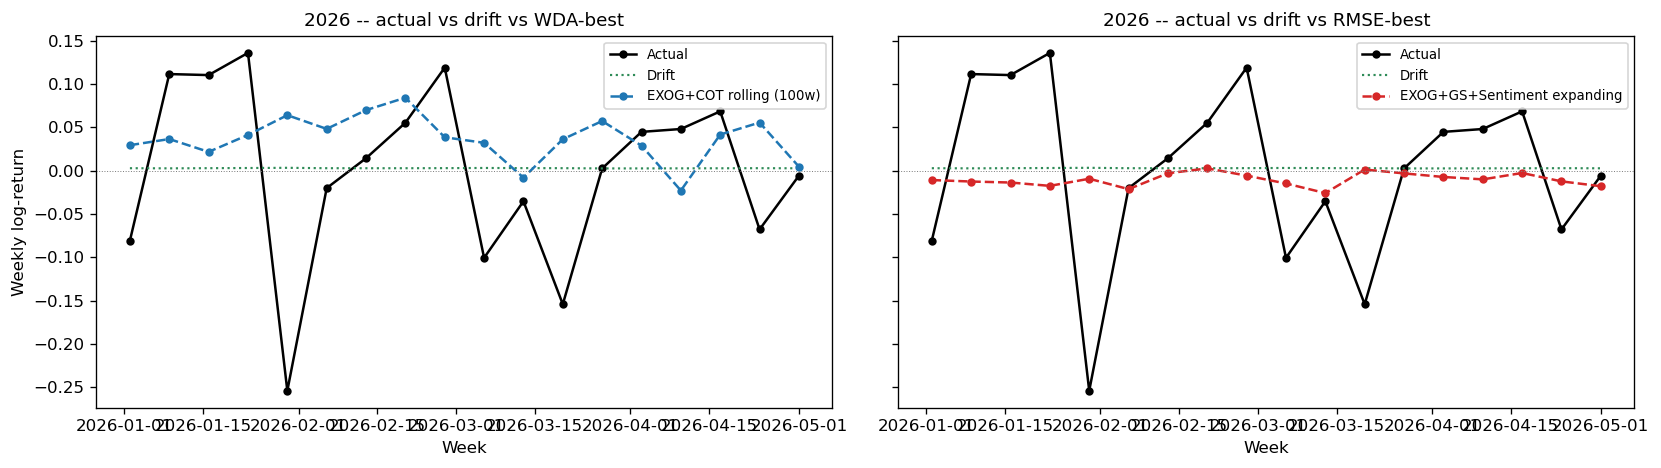

In [28]:
df26 = pd.DataFrame({'actual': y_test, 'drift': drift_pred,
                     'wda_best': best_pred, 'rmse_best': best_pred_rmse},
                    index=test_index).loc['2026':]

if df26.empty:
    print('No 2026 data in test set yet.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)
    panels = [('wda_best', best_name, '#1f77b4', 'WDA-best'),
              ('rmse_best', best_name_rmse, '#d62728', 'RMSE-best')]
    for ax, (col, vname, color, tag) in zip(axes, panels):
        ax.plot(df26.index, df26['actual'], color='black',    lw=1.5, marker='o', ms=4, label='Actual')
        ax.plot(df26.index, df26['drift'],  color='seagreen', lw=1.3, ls=':',  label='Drift')
        ax.plot(df26.index, df26[col],      color=color,      lw=1.5, marker='o', ms=4, ls='--', label=vname)
        ax.axhline(0, color='grey', lw=0.6, ls=':')
        ax.set_title(f'2026 -- actual vs drift vs {tag}', fontsize=11)
        ax.set_xlabel('Week')
        ax.legend(fontsize=8)
    axes[0].set_ylabel('Weekly log-return')
    plt.tight_layout()
    plt.show()


## 10. Granger causality tests (VAR-specific)

These diagnostics are kept after the forecasting battery because they are interpretive, not the
headline OOS methodology. Conceptually, they play the VAR-specific feature-relevance role that RF/XGB
feature-importance plots play in the tree notebooks.

For testing whether $X$ Granger-causes $Y$, compare two regressions.

Restricted model: predict $Y_t$ using only past values of $Y$:

$$
Y_t = \alpha + \sum_{i=1}^{p}\beta_i Y_{t-i} + \varepsilon_t.
$$

Unrestricted model: predict $Y_t$ using past values of both $Y$ and $X$:

$$
Y_t = \alpha + \sum_{i=1}^{p}\beta_i Y_{t-i}
      + \sum_{i=1}^{p}\gamma_i X_{t-i} + \varepsilon_t.
$$

The null is

$$
H_0: \gamma_1 = \gamma_2 = \cdots = \gamma_p = 0,
$$

meaning past $X$ adds no predictive information once past $Y$ is already included.

**Implementation detail:** the tests below are **pairwise / bivariate Granger tests**. For each row,
the restricted model uses only lagged `silver_return`; the unrestricted model adds only the one tested
predictor's lag block. It does **not** control for the rest of the VAR system. A conditional /
multivariate Granger test would ask, for example, whether USD helps after also controlling for gold,
copper, VIX, oil, etc. Here the target is weekly `silver_return`, not silver prices, because returns
are the forecasting target throughout the weekly notebooks.

For example, `usd_return -> silver_return` tests whether all USD lag coefficients are jointly zero in

$$
r^{silver}_t
= \alpha + \sum_{i=1}^{p}\beta_i r^{silver}_{t-i}
+ \sum_{i=1}^{p}\gamma_i r^{usd}_{t-i} + \varepsilon_t.
$$

The reported p-value comes from the usual nested-model F-test,

$$
F = \frac{(RSS_R - RSS_U)/p}{RSS_U/(T - 2p - 1)},
$$

where $RSS_R$ and $RSS_U$ are the restricted and unrestricted residual sums of squares. Small p-values
reject $H_0$, so $X$ Granger-causes $Y$ in the predictive sense. Important: the row `L=k` tests lags
$1,\ldots,k$ jointly; it is not a test of only lag $k$.

The code below sweeps every lag order from 1 through 10 on train+val only. Reverse sentiment tests are
included as a falsification check.


In [29]:
from IPython.display import display

train_gc = weekly.reindex(target_frame.index).iloc[:n_train].copy()
train_gc = train_gc.ffill().fillna(0.0)
MAX_GC_LAG = 10
LAGS_TO_TEST = list(range(1, MAX_GC_LAG + 1))
lag_cols = [f'L{L}' for L in LAGS_TO_TEST]


def run_gc(y_col, x_col, maxlag=MAX_GC_LAG):
    # Pairwise/bivariate Granger: restricted = y_col lags only; unrestricted = y_col + x_col lags.
    d = train_gc[[y_col, x_col]].dropna()
    res = grangercausalitytests(d, maxlag=maxlag, verbose=False)
    return {f'L{L}': res[L][0]['ssr_ftest'][1] for L in range(1, maxlag + 1)}


def gc_table(y_col, predictors):
    rows = {}
    for x_col in predictors:
        if x_col not in train_gc.columns or x_col == y_col:
            continue
        try:
            rows[x_col] = run_gc(y_col, x_col)
        except Exception as err:
            print(f'Skipping {x_col}: {err}')
    out = pd.DataFrame.from_dict(rows, orient='index')
    if out.empty:
        return out
    out['min_p'] = out[lag_cols].min(axis=1)
    out['best_lag'] = out[lag_cols].idxmin(axis=1)
    out['sig_lags'] = out[lag_cols].apply(
        lambda row: ', '.join([lag for lag, p in row.items() if p < 0.05]) or '-', axis=1)
    return out[['best_lag', 'min_p', 'sig_lags'] + lag_cols].sort_values('min_p')


def show_gc(title, table):
    print(title)
    print('-' * 90)
    if table.empty:
        print('No valid predictors.')
        return
    fmt = {'min_p': '{:.3f}', **{col: '{:.3f}' for col in lag_cols}}
    display(table.style
            .format(fmt)
            .background_gradient(cmap='RdYlGn_r', subset=['min_p'] + lag_cols, vmin=0, vmax=0.10))
    sig = table.loc[table['min_p'] < 0.05, ['best_lag', 'min_p', 'sig_lags']]
    if len(sig):
        print('Predictors with any p<0.05:')
        print(sig.to_string(float_format=lambda x: f'{x:.3f}'))
    else:
        print('No predictor rejects H0 at p<0.05 over lags 1..10.')

main_predictors = list(dict.fromkeys(EXOG_RETURNS + list(GS_COLS) + list(FRED_COLS) + list(COT_COLS)))
sent_predictors = [s for s in ['reddit_sentiment', 'news_sentiment'] if s in train_gc.columns]

show_gc(f'Granger causality -> silver_return (train+val, lags 1..{MAX_GC_LAG})',
        gc_table(TARGET, main_predictors))

show_gc(f'\nSentiment -> silver_return (train+val, lags 1..{MAX_GC_LAG})',
        gc_table(TARGET, sent_predictors))

reverse_sent = {}
for s in sent_predictors:
    try:
        reverse_sent[s] = run_gc(s, TARGET)
    except Exception as err:
        print(f'Skipping reverse test for {s}: {err}')
reverse_sent = pd.DataFrame.from_dict(reverse_sent, orient='index')
if not reverse_sent.empty:
    reverse_sent['min_p'] = reverse_sent[lag_cols].min(axis=1)
    reverse_sent['best_lag'] = reverse_sent[lag_cols].idxmin(axis=1)
    reverse_sent['sig_lags'] = reverse_sent[lag_cols].apply(
        lambda row: ', '.join([lag for lag, p in row.items() if p < 0.05]) or '-', axis=1)
    reverse_sent = reverse_sent[['best_lag', 'min_p', 'sig_lags'] + lag_cols].sort_values('min_p')
show_gc(f'\nFalsification -- silver_return -> sentiment (train+val, lags 1..{MAX_GC_LAG})',
        reverse_sent)

print('\nDecision rule: small p-values reject H0 that the predictor lags add no information.')


Granger causality -> silver_return (train+val, lags 1..10)
------------------------------------------------------------------------------------------


,best_lag,min_p,sig_lags,L1,L2,L3,L4,L5,L6,L7,L8,L9,L10
gs_ratio_z,L3,0.000,"L1, L2, L3, L4, L5, L6, L7, L8, L9, L10",0.002,0.006,0.000,0.001,0.002,0.001,0.002,0.004,0.007,0.014
jobless_chg,L10,0.011,L10,0.343,0.381,0.172,0.223,0.308,0.130,0.068,0.085,0.073,0.011
usd_return,L4,0.045,L4,0.460,0.826,0.935,0.045,0.071,0.060,0.160,0.165,0.212,0.221
gold_return,L5,0.052,-,0.443,0.084,0.094,0.267,0.052,0.066,0.061,0.095,0.123,0.160
real_rates_chg,L8,0.066,-,0.126,0.102,0.115,0.087,0.128,0.114,0.125,0.066,0.086,0.115
cot_mm_net_pct,L1,0.121,-,0.121,0.124,0.175,0.307,0.327,0.343,0.335,0.172,0.253,0.329
breakeven_chg,L8,0.192,-,0.686,0.567,0.650,0.474,0.564,0.673,0.354,0.192,0.211,0.253
oil_return,L7,0.198,-,0.443,0.475,0.204,0.205,0.208,0.309,0.198,0.257,0.293,0.362
sp500_return,L1,0.207,-,0.207,0.393,0.542,0.819,0.893,0.806,0.773,0.675,0.735,0.668
vix_return,L3,0.216,-,0.354,0.609,0.216,0.312,0.471,0.546,0.631,0.733,0.685,0.725


Predictors with any p<0.05:
            best_lag  min_p                                 sig_lags
gs_ratio_z        L3  0.000  L1, L2, L3, L4, L5, L6, L7, L8, L9, L10
jobless_chg      L10  0.011                                      L10
usd_return        L4  0.045                                       L4

Sentiment -> silver_return (train+val, lags 1..10)
------------------------------------------------------------------------------------------


,best_lag,min_p,sig_lags,L1,L2,L3,L4,L5,L6,L7,L8,L9,L10
reddit_sentiment,L8,0.279,-,0.936,0.881,0.957,0.895,0.722,0.540,0.652,0.279,0.338,0.430
news_sentiment,L1,0.362,-,0.362,0.540,0.647,0.635,0.541,0.591,0.653,0.752,0.630,0.482


No predictor rejects H0 at p<0.05 over lags 1..10.

Falsification -- silver_return -> sentiment (train+val, lags 1..10)
------------------------------------------------------------------------------------------


,best_lag,min_p,sig_lags,L1,L2,L3,L4,L5,L6,L7,L8,L9,L10
news_sentiment,L5,0.159,-,0.589,0.686,0.648,0.646,0.159,0.275,0.304,0.432,0.497,0.303
reddit_sentiment,L6,0.638,-,0.760,0.911,0.942,0.796,0.848,0.638,0.721,0.764,0.858,0.773


No predictor rejects H0 at p<0.05 over lags 1..10.

Decision rule: small p-values reject H0 that the predictor lags add no information.


## 11. Impulse response functions (VAR-specific)

IRFs are shown for the parsimonious EXOG system selected in §2, not for the high-dimensional ablation
rungs. This keeps the plot interpretable. Responses are orthogonalised one-standard-deviation shocks
using the displayed variable order, so they are useful as a descriptive propagation check rather than
a causal structural claim.


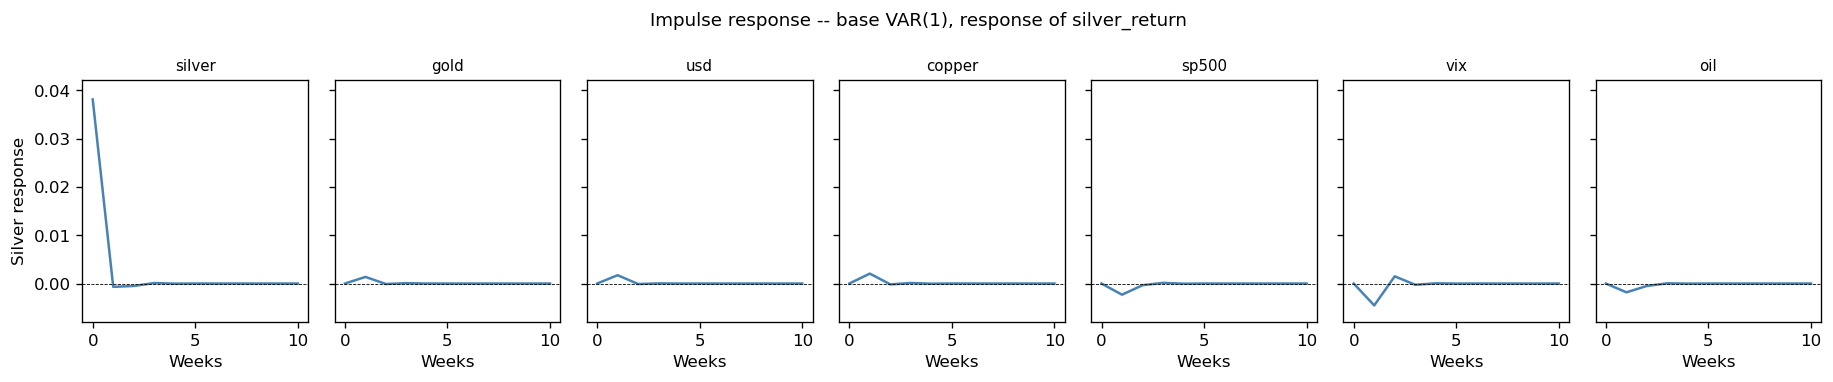

In [30]:
irf_periods = 10
fitted = VAR(base_system.iloc[:n_train]).fit(base_lag)
irf = fitted.irf(periods=irf_periods)
silver_idx = base_system.columns.get_loc(TARGET)
shock_cols = base_system.columns.tolist()

try:
    lower, upper = irf.errband_mc(orth=True, repl=500, signif=0.05, seed=42)
except Exception:
    lower, upper = None, None

fig, axes = plt.subplots(1, len(shock_cols), figsize=(max(14, 2.2 * len(shock_cols)), 3.2), sharey=True)
if len(shock_cols) == 1:
    axes = [axes]
weeks = np.arange(irf_periods + 1)
for j, col in enumerate(shock_cols):
    response = irf.orth_irfs[:, silver_idx, j]
    axes[j].plot(weeks, response, color='steelblue', lw=1.5)
    if lower is not None and upper is not None:
        axes[j].fill_between(weeks, lower[:, silver_idx, j], upper[:, silver_idx, j],
                             color='steelblue', alpha=0.15, linewidth=0)
    axes[j].axhline(0, color='black', lw=0.5, ls='--')
    axes[j].set_title(col.replace('_return', '').replace('silver_', 'silver '), fontsize=9)
    axes[j].set_xlabel('Weeks')
axes[0].set_ylabel('Silver response')
fig.suptitle(f'Impulse response -- base VAR({base_lag}), response of silver_return', fontsize=11)
plt.tight_layout()
plt.show()
